In [8]:
import pandas as pd

orders = pd.read_csv('/Users/husnabayraktar/Desktop/forecasting-project/data/raw/olist_orders_dataset.csv')
customers = pd.read_csv('/Users/husnabayraktar/Desktop/forecasting-project/data/raw/olist_customers_dataset.csv')

print("Orders shape:", orders.shape)
print("Customers shape:", customers.shape)

orders.head()

Orders shape: (99441, 8)
Customers shape: (99441, 5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [9]:
orders.info()
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null 

In [10]:
# Convert purchase timestamp to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Keep only delivered orders
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

print("Delivered orders:", orders_delivered.shape)

Delivered orders: (96478, 8)


In [11]:
# Join orders with customer location
merged_data = orders_delivered.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

print("Merged data shape:", merged_data.shape)
merged_data.head()

Merged data shape: (96478, 9)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,SP


In [12]:
# Create weekly bucket
merged_data['week_start'] = merged_data['order_purchase_timestamp'].dt.to_period('W').apply(lambda r: r.start_time)

merged_data[['order_purchase_timestamp', 'week_start']].head()

,order_purchase_timestamp,week_start
0,2017-10-02 10:56:33,2017-10-02
1,2018-07-24 20:41:37,2018-07-23
2,2018-08-08 08:38:49,2018-08-06
3,2017-11-18 19:28:06,2017-11-13
4,2018-02-13 21:18:39,2018-02-12


In [13]:
weekly_demand = (
    merged_data
    .groupby(['week_start', 'customer_state'])
    .size()
    .reset_index(name='total_orders')
)

weekly_demand.head()

,week_start,customer_state,total_orders
0,2016-09-12,SP,1
1,2016-10-03,AL,1
2,2016-10-03,BA,2
3,2016-10-03,CE,6
4,2016-10-03,DF,5


In [14]:
sp_demand = weekly_demand[weekly_demand['customer_state'] == 'SP'].copy()

print("SP weekly rows:", sp_demand.shape)
sp_demand.head()

SP weekly rows: (90, 3)


,week_start,customer_state,total_orders
0,2016-09-12,SP,1
19,2016-10-03,SP,84
32,2016-10-10,SP,10
41,2017-01-02,SP,4
54,2017-01-09,SP,21


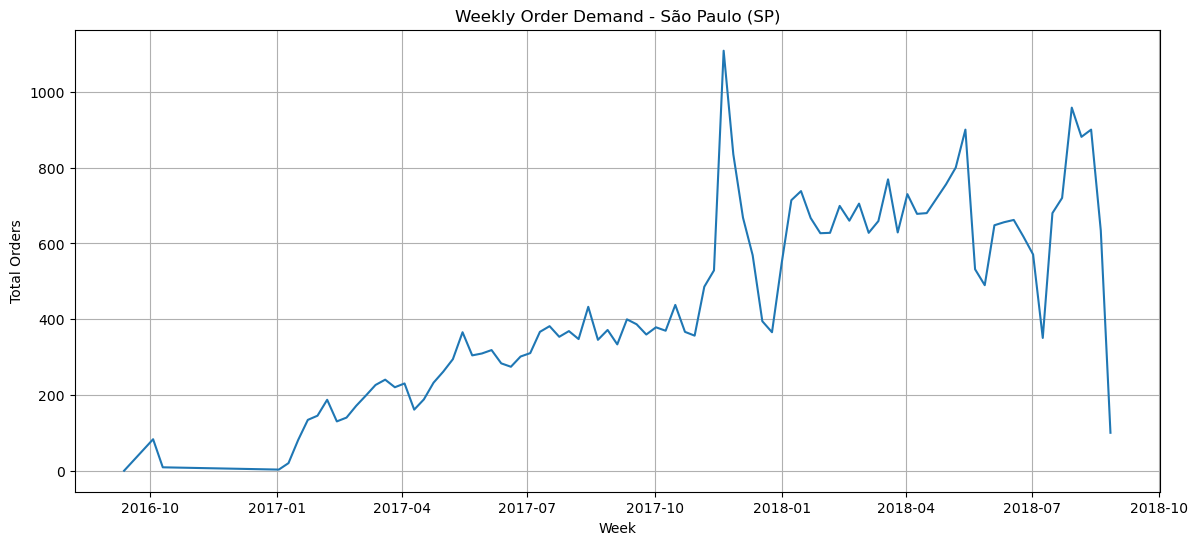

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(sp_demand['week_start'], sp_demand['total_orders'])
plt.title('Weekly Order Demand - São Paulo (SP)')
plt.xlabel('Week')
plt.ylabel('Total Orders')
plt.grid(True)
plt.show()

In [16]:
prophet_df = sp_demand[['week_start', 'total_orders']].copy()

prophet_df.columns = ['ds', 'y']

# Sort by date just to be safe
prophet_df = prophet_df.sort_values('ds')

prophet_df.head()

,ds,y
0,2016-09-12,1
19,2016-10-03,84
32,2016-10-10,10
41,2017-01-02,4
54,2017-01-09,21


In [17]:
prophet_df = prophet_df.iloc[:-1]

print("Prophet dataset shape:", prophet_df.shape)
prophet_df.tail()

Prophet dataset shape: (89, 2)


,ds,y
2051,2018-07-23,720
2075,2018-07-30,958
2100,2018-08-06,881
2125,2018-08-13,900
2145,2018-08-20,634


In [18]:
from prophet import Prophet
print("Prophet installed successfully")

ModuleNotFoundError: No module named 'prophet'

In [19]:
!pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 27.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [prophet]m4/5 [prophet]y]


In [20]:
from prophet import Prophet

# Create model
model = Prophet()

# Train model
model.fit(prophet_df)

12:56:50 - cmdstanpy - INFO - Chain [1] start processing
12:56:51 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
future = model.make_future_dataframe(periods=12, freq='W')

future.tail()

,ds
96,2018-10-14
97,2018-10-21
98,2018-10-28
99,2018-11-04
100,2018-11-11


In [22]:
forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

,ds,yhat,yhat_lower,yhat_upper
89,2018-08-26,820.807736,665.439758,959.137898
90,2018-09-02,828.912937,669.980212,985.019983
91,2018-09-09,837.018139,689.633917,995.678581
92,2018-09-16,845.123340,693.477031,1008.752906
93,2018-09-23,853.228542,696.060627,1012.249246
94,2018-09-30,861.333743,704.603358,1006.172127
95,2018-10-07,869.438945,717.020108,1024.274184
96,2018-10-14,877.544146,725.476255,1025.961943
97,2018-10-21,885.649348,731.346303,1034.998844
98,2018-10-28,893.754549,733.007469,1049.246488


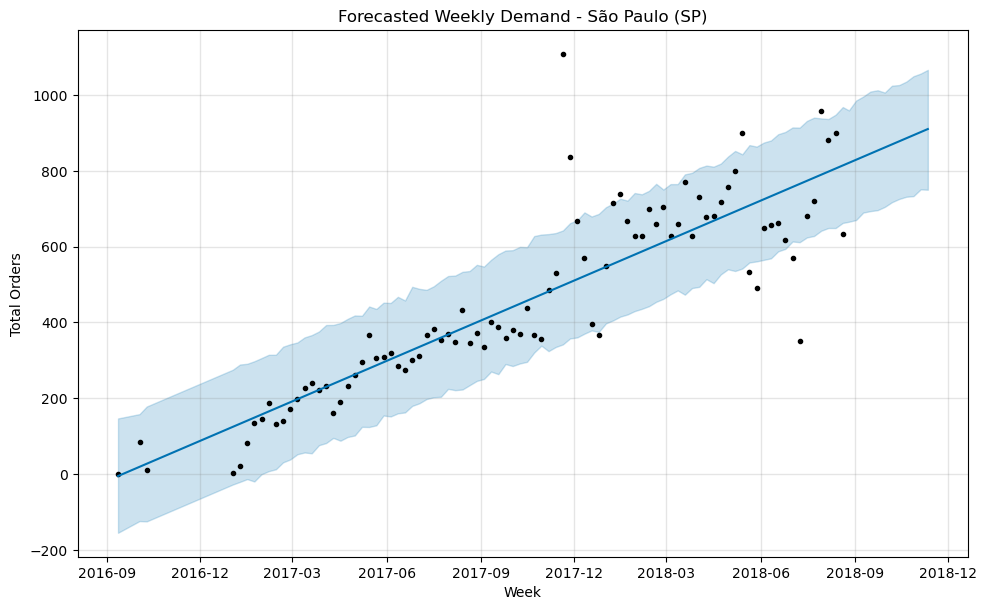

In [23]:
import matplotlib.pyplot as plt

fig = model.plot(forecast)
plt.title("Forecasted Weekly Demand - São Paulo (SP)")
plt.xlabel("Week")
plt.ylabel("Total Orders")
plt.show()

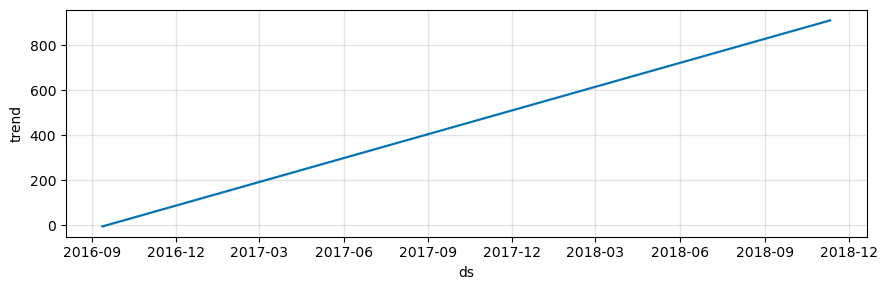

In [24]:
fig2 = model.plot_components(forecast)
plt.show()

In [26]:
forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

forecast_output.to_csv(
    '/Users/husnabayraktar/Desktop/forecasting-project/output/sp_forecast_results.csv',
    index=False
)

print("Forecast results saved successfully")

Forecast results saved successfully


In [27]:
weekly_demand.to_csv(
    '/Users/husnabayraktar/Desktop/forecasting-project/output/weekly_demand_all_states.csv',
    index=False
)

print("Weekly demand dataset saved successfully")

Weekly demand dataset saved successfully
